In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
try:
    from google.colab import files

    print("Please select your cleaned Layoffs CSV file.")
    uploaded = files.upload()

    file_name = next(iter(uploaded.keys()))

except ImportError:
    print("Google Colab upload is not available.")
    print("Enter the path of your CSV file below.")
    file_name = input("CSV file path: ").strip()

print("\nSelected file:", file_name)

df = pd.read_csv(file_name)

print("\nDataset loaded successfully!")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

Please select your cleaned Layoffs CSV file.


Saving layoffs_cleaned_final.csv to layoffs_cleaned_final.csv

Selected file: layoffs_cleaned_final.csv

Dataset loaded successfully!
Rows    : 5676
Columns : 21


In [3]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Records:")
display(df.head())

print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (5676, 21)

First 5 Records:


,record_id,company,city,country,is_us,industry,stage,company_size_before,company_size_after,total_laid_off,percentage_laid_off,funds_raised_mil,date,year,date_added,status,quarter,month_name,day_of_week,is_weekend,days_to_report
0,layoff_01916,Kaiyo,NEW YORK CITY,United States,True,Retail,Series B,397,633.00,54.00,100.00,43.00,2024-08-21,2024,2024-08-22,Unknown,3,August,Wednesday,False,1
1,layoff_00360,Trell,Bengaluru,India,False,Retail,Unknown,600,300.00,300.00,50.00,62.00,2022-03-15,2022,2022-05-07,Unknown,1,March,Tuesday,False,53
2,layoff_02462,Flowhub,Dever,unknown,False,Cannabis,Unknown,700,700.00,25.00,15.00,974.00,2022-09-09,2022,2022-09-09,Private,3,September,Friday,False,0
3,layoff_01425,trigo,Tel Aviv,Israel,False,Retail,Series C,200,170.00,30.00,15.00,199.00,2024-01-04,2024,2024-01-05,Unknown,1,January,Thursday,False,1
4,layoff_03829,New Relic,Unknown,United States,True,INFRASTRUCTURE,Post-IPO,2550,30.00,255.00,10.00,173.00,2023-06-27,2023,2023-06-27,Unknown,2,June,Tuesday,False,0



Column Names:
1. record_id
2. company
3. city
4. country
5. is_us
6. industry
7. stage
8. company_size_before
9. company_size_after
10. total_laid_off
11. percentage_laid_off
12. funds_raised_mil
13. date
14. year
15. date_added
16. status
17. quarter
18. month_name
19. day_of_week
20. is_weekend
21. days_to_report

Data Types:


,0
record_id,object
company,object
city,object
country,object
is_us,bool
industry,object
stage,object
company_size_before,int64
company_size_after,float64
total_laid_off,float64



Missing Values:


,0
record_id,0
company,0
city,0
country,0
is_us,0
industry,0
stage,0
company_size_before,0
company_size_after,0
total_laid_off,0



Duplicate Rows: 0


In [4]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

descriptive_stats = df[numeric_columns].describe().T

display(descriptive_stats)

Numerical Columns:
['company_size_before', 'company_size_after', 'total_laid_off', 'percentage_laid_off', 'funds_raised_mil', 'year', 'quarter', 'days_to_report']


,count,mean,std,min,25%,50%,75%,max
company_size_before,"5,676.00","6,165.29","39,751.82",0.00,230.00,650.00,"1,900.00","1,400,000.00"
company_size_after,"5,676.00","3,873.01","31,311.46",0.00,139.00,400.00,"1,057.00","600,000.00"
total_laid_off,"5,676.00",333.36,"1,212.79",0.00,45.00,95.00,200.00,"30,000.00"
percentage_laid_off,"5,676.00",26.13,27.08,0.00,10.00,17.00,28.00,100.00
funds_raised_mil,"5,676.00",843.48,"5,111.41",0.00,65.00,173.00,423.00,"121,900.00"
year,"5,676.00","2,022.78",1.55,"2,020.00","2,022.00","2,023.00","2,024.00","2,026.00"
quarter,"5,676.00",2.39,1.08,1.00,1.00,2.00,3.00,4.00
days_to_report,"5,676.00",9.16,49.31,0.00,0.00,1.00,2.00,"1,292.00"


In [5]:
stats_table = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Std Dev": df[numeric_columns].std(),
    "Variance": df[numeric_columns].var(),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max(),
    "Skewness": df[numeric_columns].skew(),
    "Kurtosis": df[numeric_columns].kurt()
})

display(stats_table)

,Mean,Median,Mode,Std Dev,Variance,Minimum,Maximum,Skewness,Kurtosis
company_size_before,"6,165.29",650.00,"1,000.00","39,751.82","1,580,206,987.52",0.00,"1,400,000.00",16.73,388.79
company_size_after,"3,873.01",400.00,0.00,"31,311.46","980,407,808.70",0.00,"600,000.00",16.37,290.38
total_laid_off,333.36,95.00,100.00,"1,212.79","1,470,853.01",0.00,"30,000.00",10.47,150.88
percentage_laid_off,26.13,17.00,17.00,27.08,733.33,0.00,100.00,1.92,2.56
funds_raised_mil,843.48,173.00,173.00,"5,111.41","26,126,541.45",0.00,"121,900.00",19.47,444.19
year,"2,022.78","2,023.00","2,022.00",1.55,2.40,"2,020.00","2,026.00",-0.03,-0.26
quarter,2.39,2.00,2.00,1.08,1.17,1.00,4.00,0.18,-1.25
days_to_report,9.16,1.00,0.00,49.31,"2,431.24",0.00,"1,292.00",13.71,254.80


Top 15 Industries:


,Number of Records
industry,
Finance,529
Healthcare,321
Retail,320
Consumer,312
Other,281
Unknown,264
Transportation,262
Food,241
Marketing,201


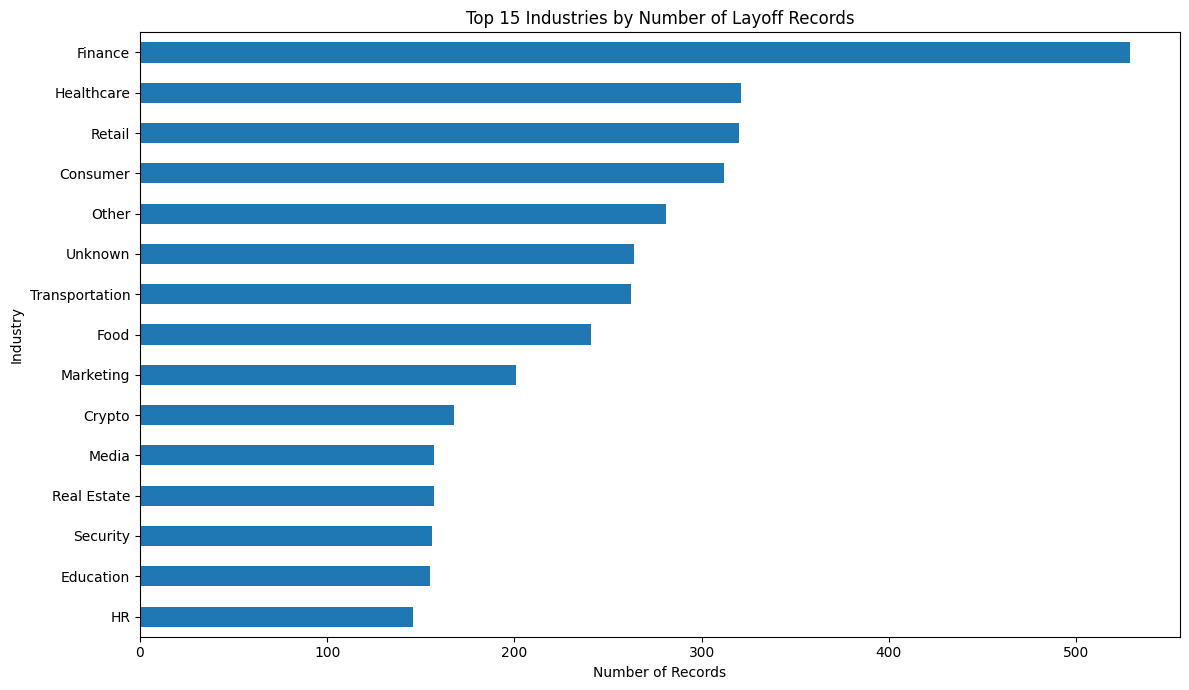

In [6]:
industry_counts = df["industry"].value_counts()

print("Top 15 Industries:")
display(industry_counts.head(15).to_frame("Number of Records"))

plt.figure(figsize=(12, 7))
industry_counts.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Industries by Number of Layoff Records")
plt.xlabel("Number of Records")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

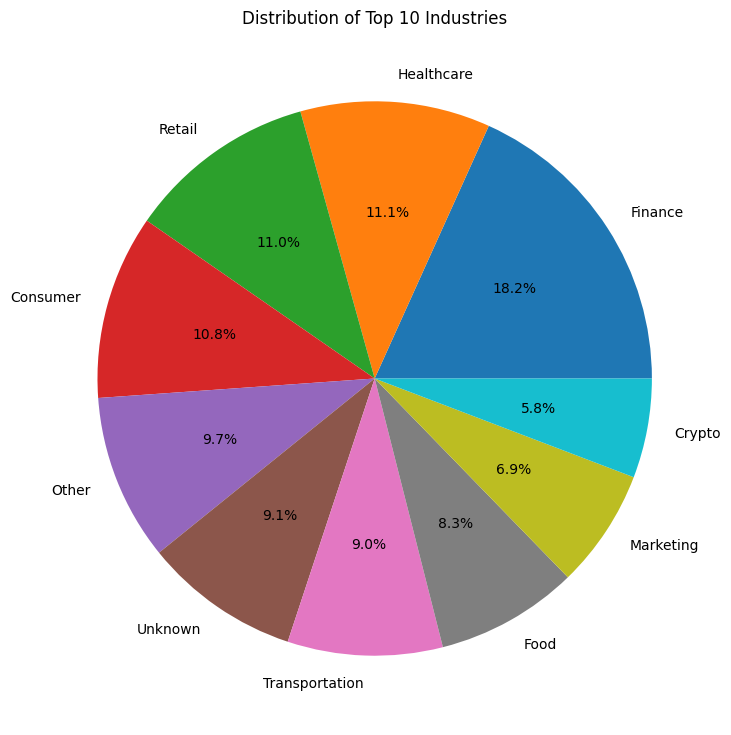

In [7]:
plt.figure(figsize=(9, 9))

industry_counts.head(10).plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Distribution of Top 10 Industries")
plt.ylabel("")
plt.show()

,Records,Total_Laid_Off,Average_Laid_Off
year,,,
2020,739,"156,072.00",211.19
2021,50,"19,225.00",384.50
2022,1635,"372,934.00",228.09
2023,1607,"547,432.00",340.65
2024,854,"327,219.00",383.16
2025,517,"326,073.00",630.70
2026,274,"143,213.00",522.68


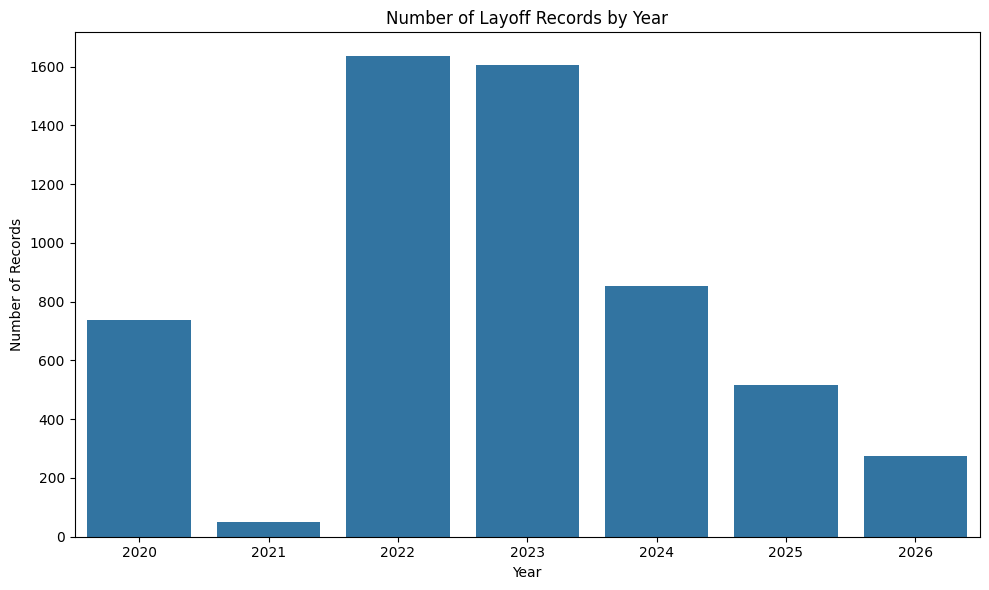

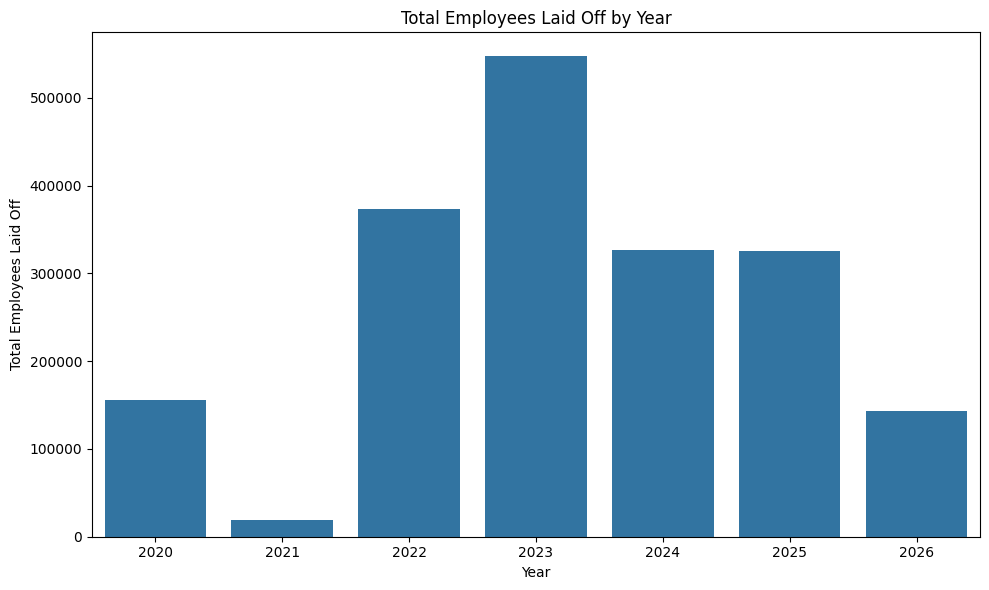

In [8]:
year_summary = df.groupby("year").agg(
    Records=("company", "count"),
    Total_Laid_Off=("total_laid_off", "sum"),
    Average_Laid_Off=("total_laid_off", "mean")
)

display(year_summary)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=year_summary.index,
    y=year_summary["Records"]
)
plt.title("Number of Layoff Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=year_summary.index,
    y=year_summary["Total_Laid_Off"]
)
plt.title("Total Employees Laid Off by Year")
plt.xlabel("Year")
plt.ylabel("Total Employees Laid Off")
plt.tight_layout()
plt.show()

,Records,Total_Laid_Off
quarter,,
1,1466,"594,434.00"
2,1745,"507,806.00"
3,1273,"370,632.00"
4,1192,"419,296.00"


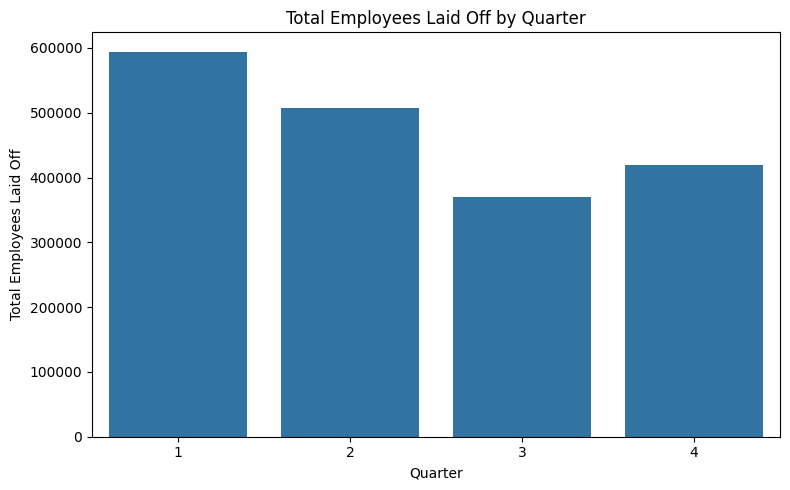

In [9]:
quarter_summary = df.groupby("quarter").agg(
    Records=("company", "count"),
    Total_Laid_Off=("total_laid_off", "sum")
)

display(quarter_summary)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=quarter_summary.index,
    y=quarter_summary["Total_Laid_Off"]
)
plt.title("Total Employees Laid Off by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Total Employees Laid Off")
plt.tight_layout()
plt.show()

,Number of Records
day_of_week,
Wednesday,1322
Thursday,1240
Tuesday,1205
Monday,840
Friday,822
Sunday,139
Saturday,108


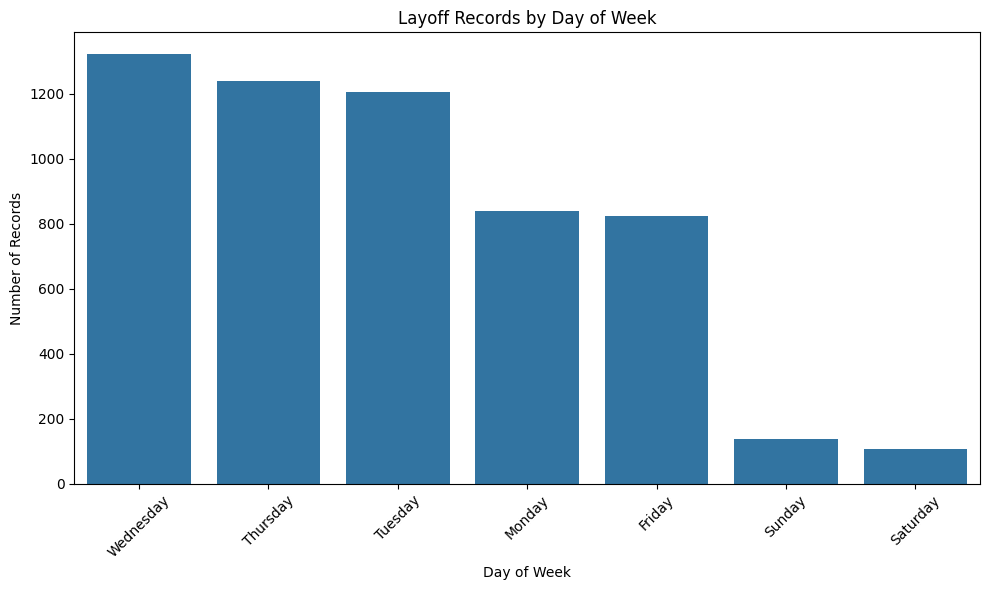

In [10]:
day_counts = df["day_of_week"].value_counts()

display(day_counts.to_frame("Number of Records"))

plt.figure(figsize=(10, 6))
sns.barplot(
    x=day_counts.index,
    y=day_counts.values
)
plt.title("Layoff Records by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Number of Records
is_weekend,
False,5429
True,247


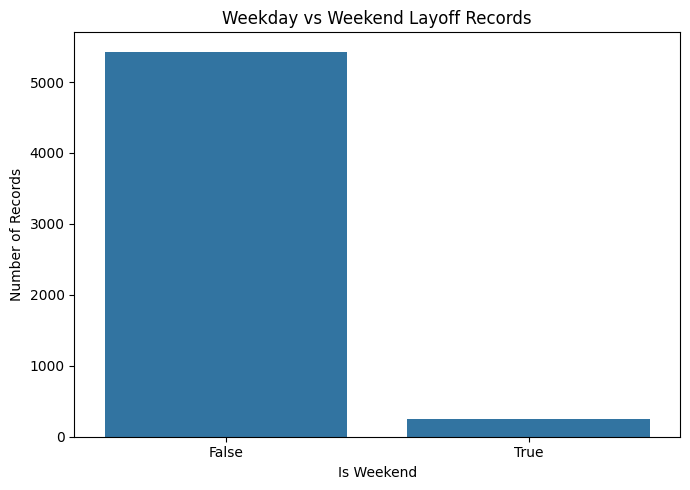

In [11]:
weekend_counts = df["is_weekend"].value_counts()

display(weekend_counts.to_frame("Number of Records"))

plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x="is_weekend"
)
plt.title("Weekday vs Weekend Layoff Records")
plt.xlabel("Is Weekend")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

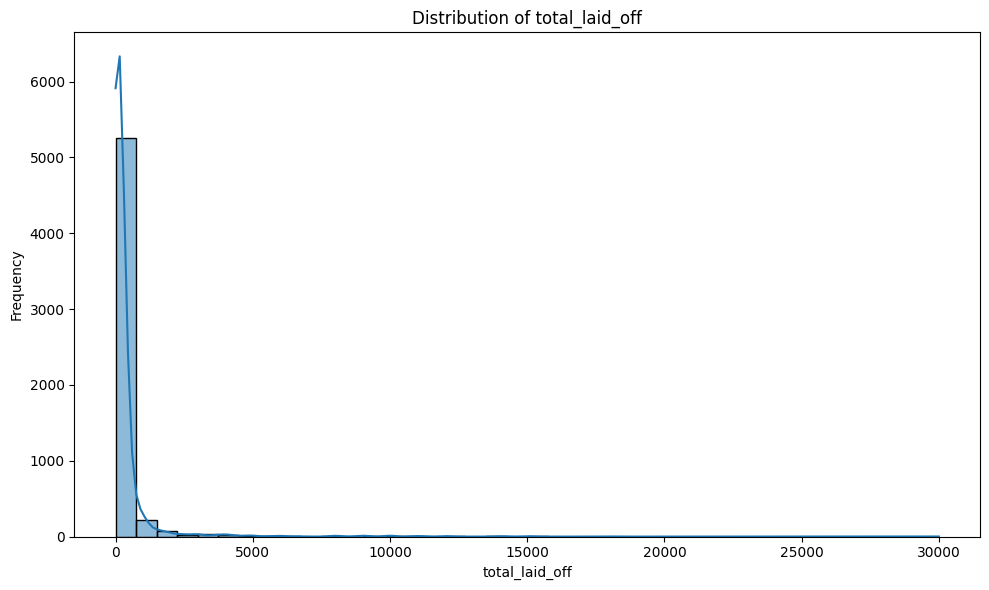

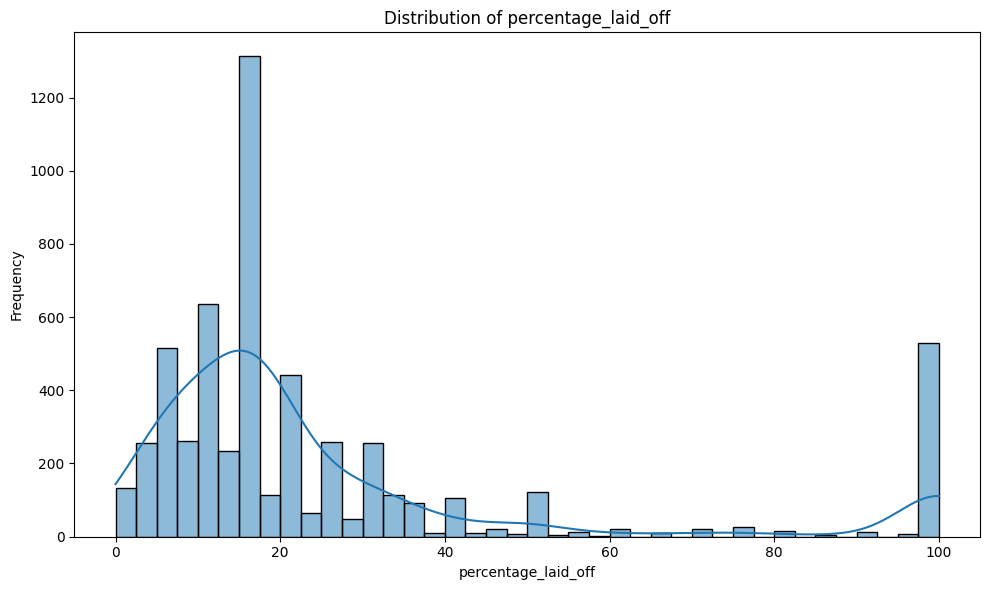

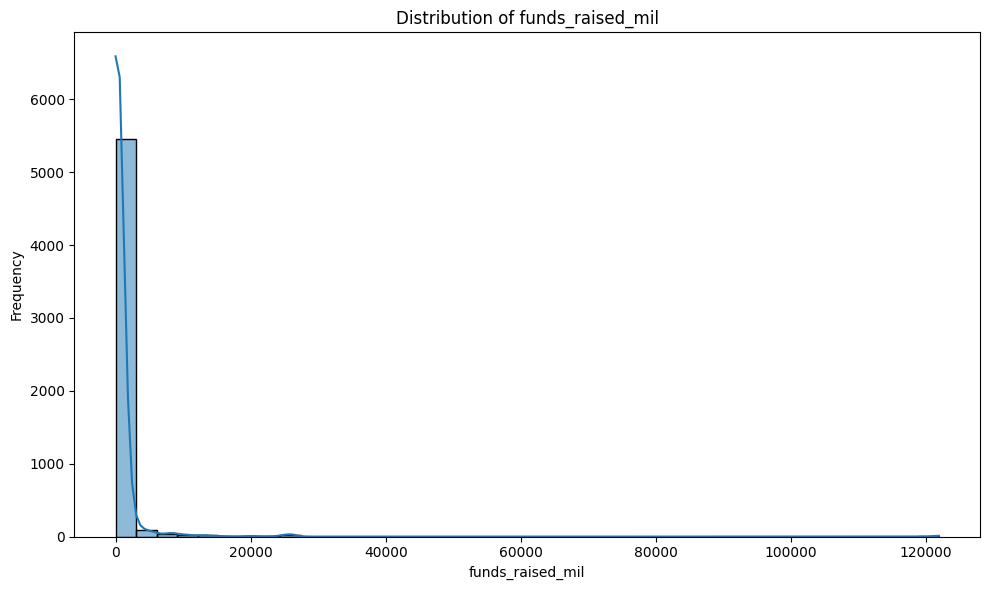

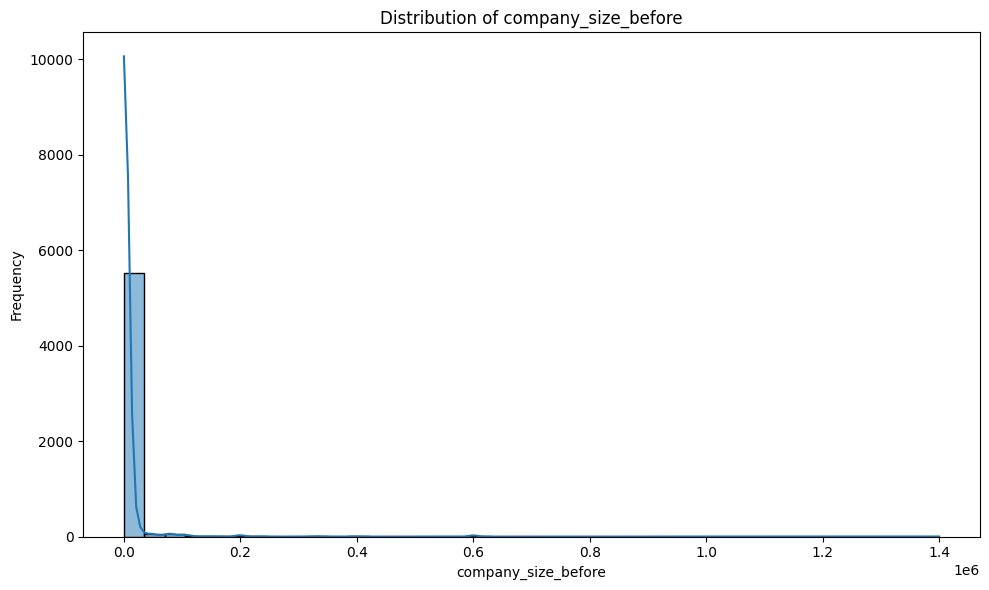

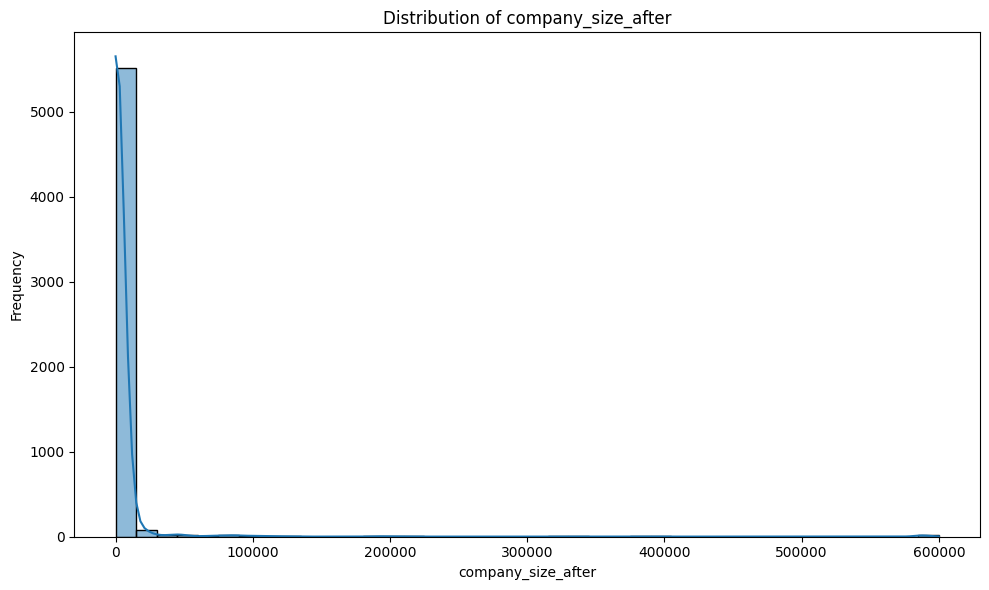

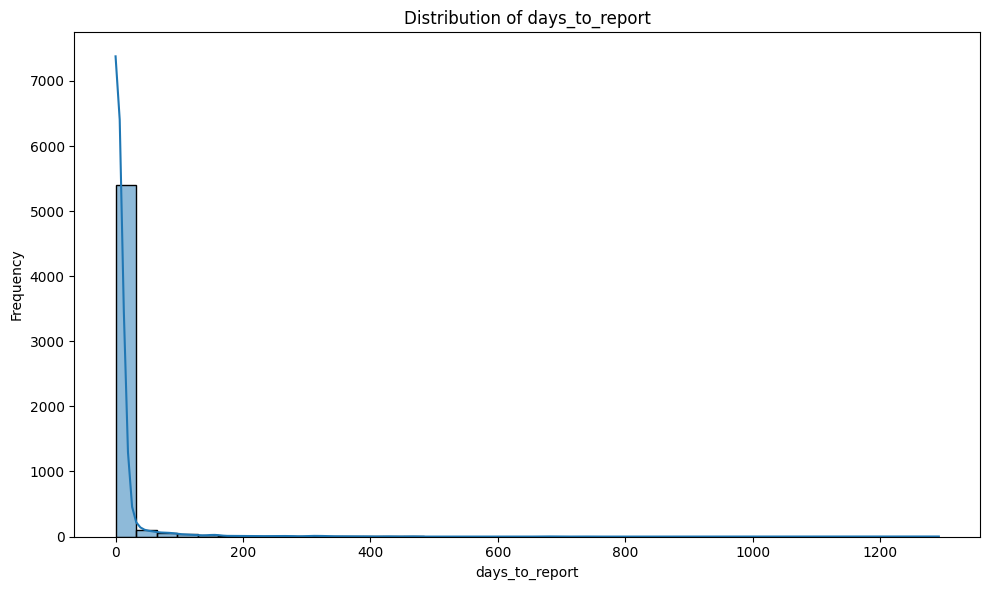

In [12]:
features_for_analysis = [
    "total_laid_off",
    "percentage_laid_off",
    "funds_raised_mil",
    "company_size_before",
    "company_size_after",
    "days_to_report"
]

for feature in features_for_analysis:

    if feature not in df.columns:
        print(f"Skipping {feature} - column not found.")
        continue

    plt.figure(figsize=(10, 6))

    sns.histplot(
        df[feature].dropna(),
        bins=40,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

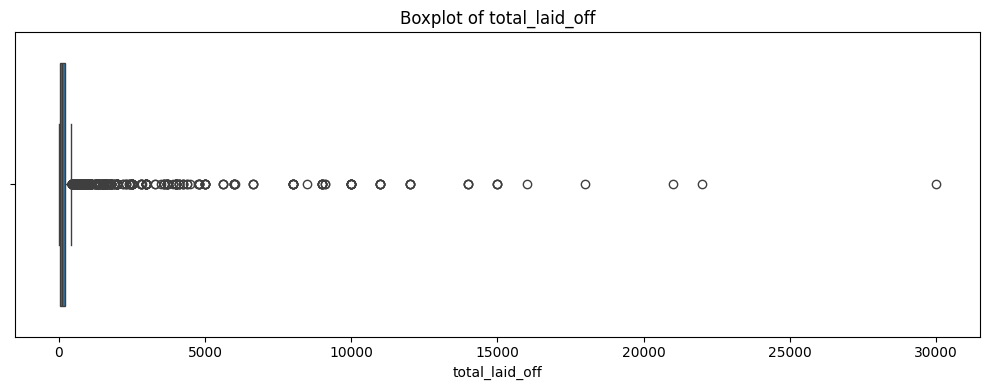

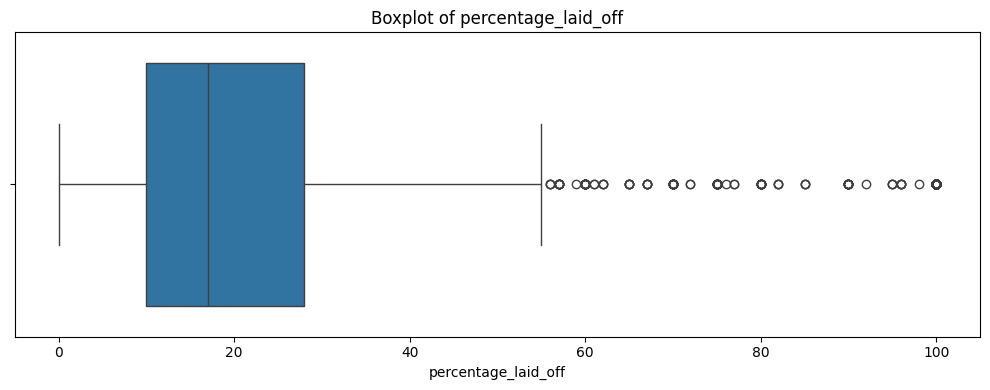

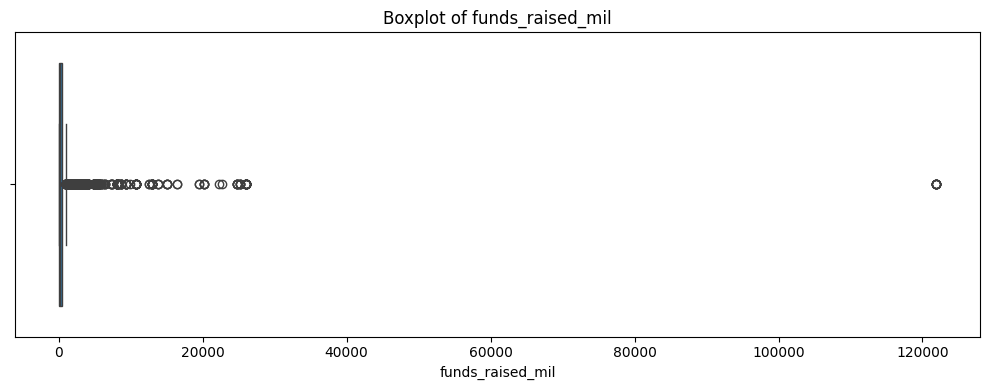

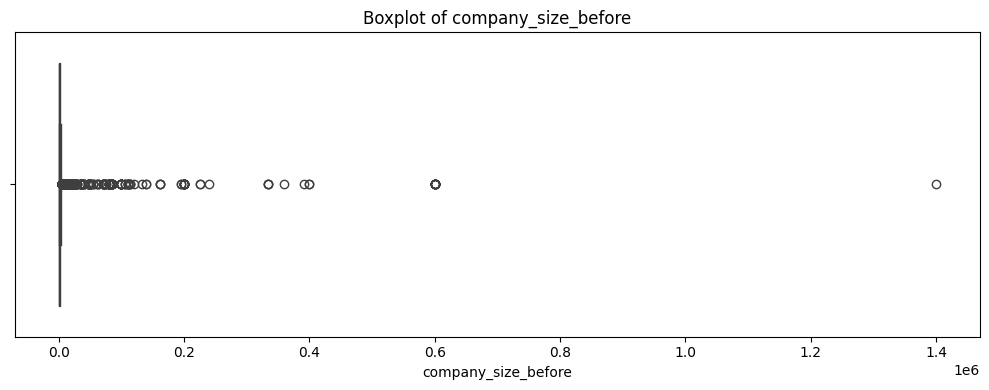

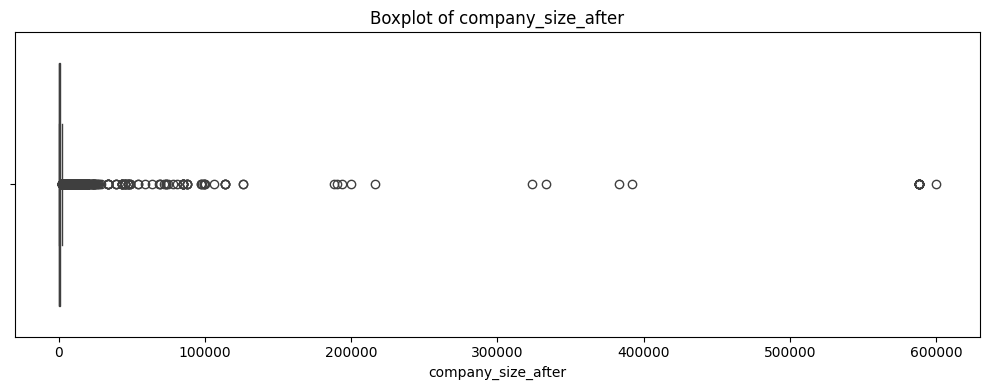

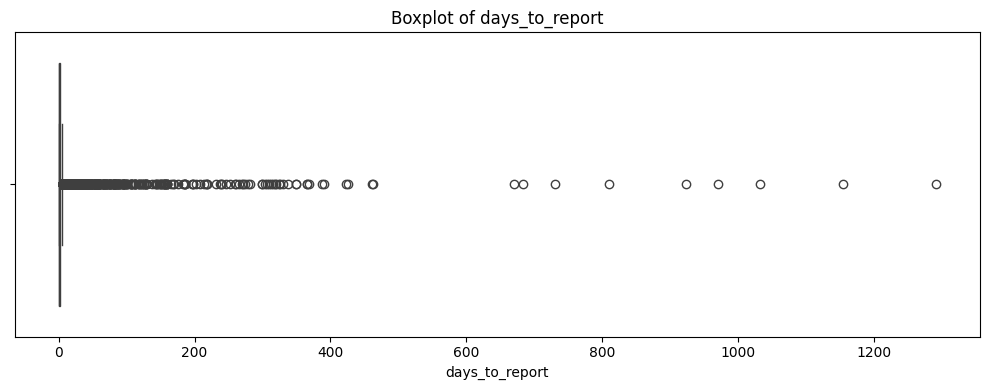

In [13]:
for feature in features_for_analysis:

    if feature not in df.columns:
        continue

    plt.figure(figsize=(10, 4))

    sns.boxplot(
        x=df[feature].dropna()
    )

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

In [14]:
def detect_outliers_iqr(data, column):

    values = data[column].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = values[
        (values < lower_bound) |
        (values > upper_bound)
    ]

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    }


outlier_results = {}

for feature in features_for_analysis:

    if feature in df.columns:
        outlier_results[feature] = detect_outliers_iqr(
            df,
            feature
        )

outlier_table = pd.DataFrame(outlier_results).T

display(outlier_table)

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
total_laid_off,45.00,200.00,155.00,-187.50,432.50,679.00
percentage_laid_off,10.00,28.00,18.00,-17.00,55.00,661.00
funds_raised_mil,65.00,423.00,358.00,-472.00,960.00,638.00
company_size_before,230.00,"1,900.00","1,670.00","-2,275.00","4,405.00",816.00
company_size_after,139.00,"1,057.00",918.00,"-1,238.00","2,434.00",744.00
days_to_report,0.00,2.00,2.00,-3.00,5.00,832.00


,Skewness
total_laid_off,10.47
percentage_laid_off,1.92
funds_raised_mil,19.47
company_size_before,16.73
company_size_after,16.37
days_to_report,13.71


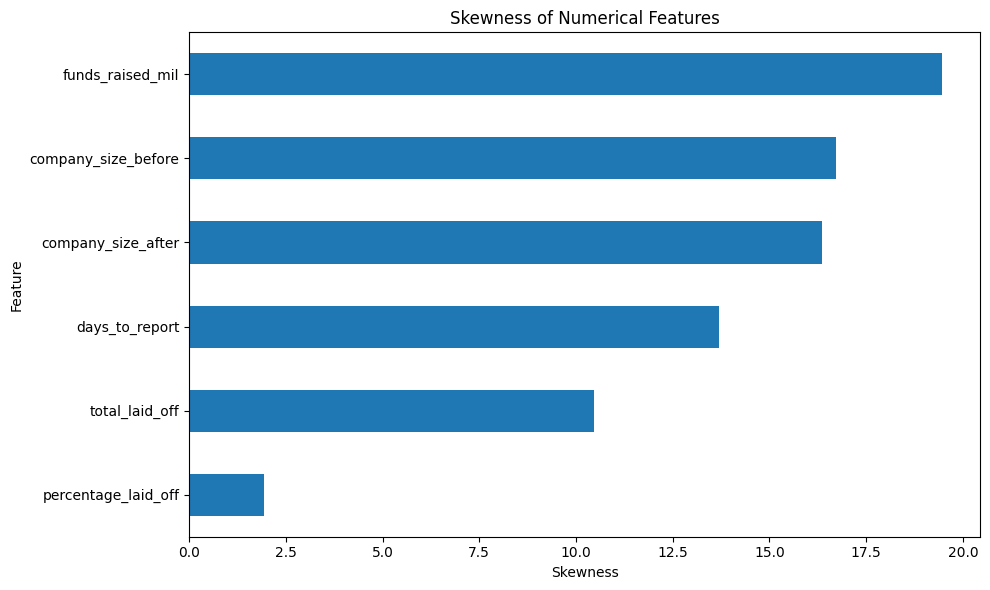

In [15]:
skewness = df[
    [f for f in features_for_analysis if f in df.columns]
].skew()

display(skewness.to_frame("Skewness"))

plt.figure(figsize=(10, 6))

skewness.sort_values().plot(
    kind="barh"
)

plt.title("Skewness of Numerical Features")
plt.xlabel("Skewness")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [16]:
correlation_features = [
    "company_size_before",
    "company_size_after",
    "total_laid_off",
    "percentage_laid_off",
    "funds_raised_mil",
    "year",
    "quarter",
    "days_to_report"
]

correlation_features = [
    col for col in correlation_features
    if col in df.columns
]

correlation_matrix = df[
    correlation_features
].corr()

display(correlation_matrix)

,company_size_before,company_size_after,total_laid_off,percentage_laid_off,funds_raised_mil,year,quarter,days_to_report
company_size_before,1.00,0.80,0.32,-0.07,0.03,0.09,0.03,-0.01
company_size_after,0.80,1.00,0.19,-0.07,0.02,0.08,0.03,-0.00
total_laid_off,0.32,0.19,1.00,-0.03,0.07,0.09,-0.02,-0.01
percentage_laid_off,-0.07,-0.07,-0.03,1.00,-0.05,0.02,0.03,0.01
funds_raised_mil,0.03,0.02,0.07,-0.05,1.00,0.02,-0.03,-0.01
year,0.09,0.08,0.09,0.02,0.02,1.00,-0.08,-0.01
quarter,0.03,0.03,-0.02,0.03,-0.03,-0.08,1.00,0.01
days_to_report,-0.01,-0.00,-0.01,0.01,-0.01,-0.01,0.01,1.00


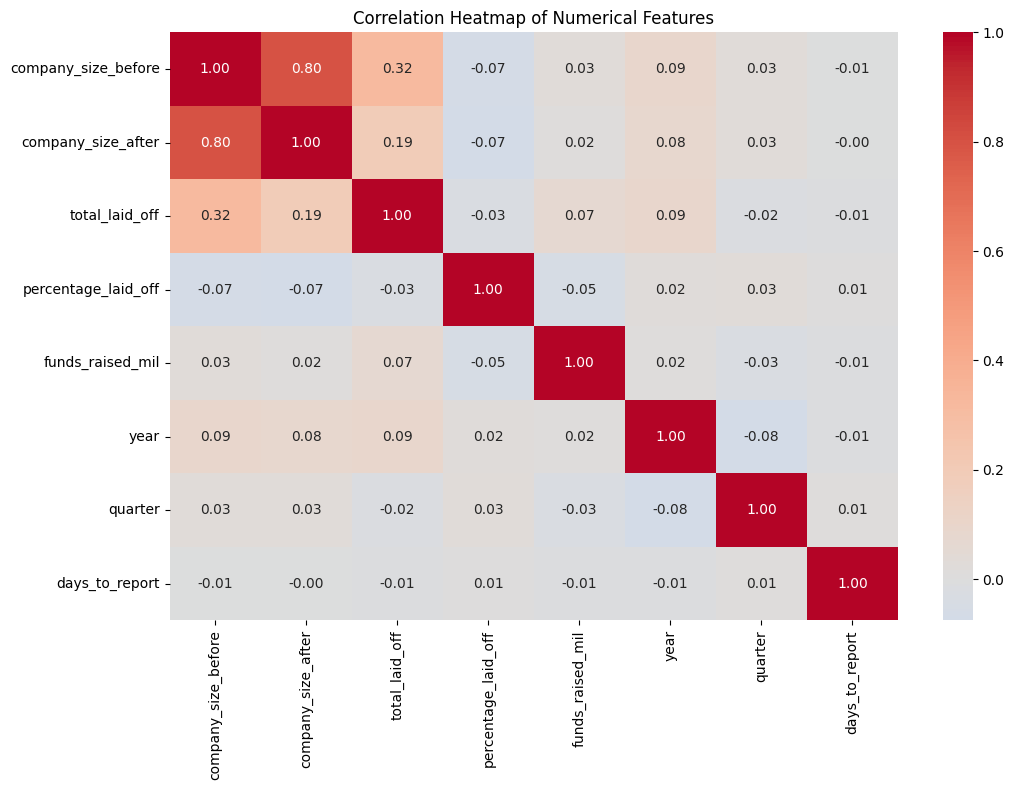

In [17]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [18]:
pairs = [
    ("company_size_before", "company_size_after"),
    ("company_size_before", "total_laid_off"),
    ("company_size_after", "total_laid_off"),
    ("total_laid_off", "funds_raised_mil"),
    ("total_laid_off", "percentage_laid_off")
]

for x, y in pairs:

    if x not in df.columns or y not in df.columns:
        continue

    subset = df[[x, y]].dropna()

    correlation, p = stats.pearsonr(
        subset[x],
        subset[y]
    )

    print(f"{x} vs {y}")
    print(f"Pearson Correlation = {correlation:.4f}")
    print(f"P-value = {p:.6f}")
    print("-" * 50)

company_size_before vs company_size_after
Pearson Correlation = 0.7957
P-value = 0.000000
--------------------------------------------------
company_size_before vs total_laid_off
Pearson Correlation = 0.3166
P-value = 0.000000
--------------------------------------------------
company_size_after vs total_laid_off
Pearson Correlation = 0.1941
P-value = 0.000000
--------------------------------------------------
total_laid_off vs funds_raised_mil
Pearson Correlation = 0.0675
P-value = 0.000000
--------------------------------------------------
total_laid_off vs percentage_laid_off
Pearson Correlation = -0.0289
P-value = 0.029580
--------------------------------------------------


,Total Employees Laid Off
industry,
Consumer,"180,321.00"
Hardware,"147,106.00"
Retail,"144,786.00"
Other,"139,615.00"
Finance,"107,524.00"
Transportation,"90,956.00"
Food,"82,253.00"
Unknown,"64,529.00"
Healthcare,"55,336.00"


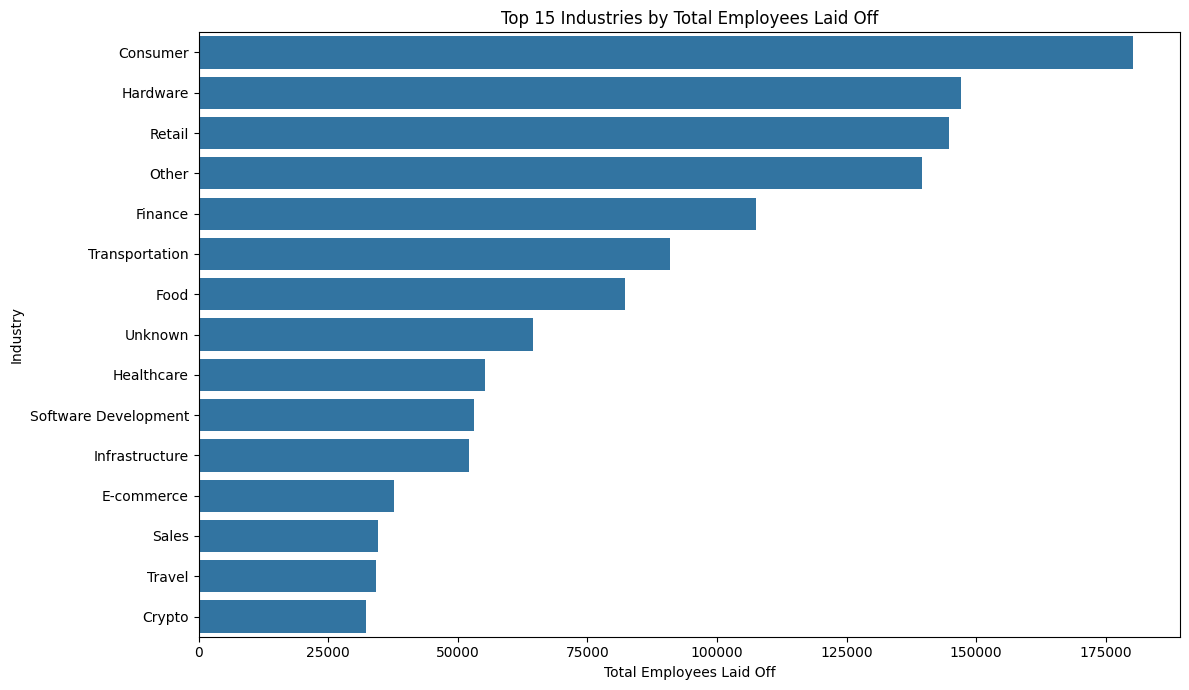

In [19]:
industry_layoffs = (
    df.groupby("industry")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
)

display(industry_layoffs.head(15).to_frame("Total Employees Laid Off"))

plt.figure(figsize=(12, 7))

sns.barplot(
    x=industry_layoffs.head(15).values,
    y=industry_layoffs.head(15).index
)

plt.title("Top 15 Industries by Total Employees Laid Off")
plt.xlabel("Total Employees Laid Off")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

,Total Employees Laid Off
country,
United States,"1,258,380.00"
Unknown,"101,586.00"
India,"95,979.00"
unknown,"71,412.00"
Germany,"51,986.00"
United Kingdom,"41,375.00"
Israel,"39,768.00"
Netherlands,"28,637.00"
Canada,"27,359.00"


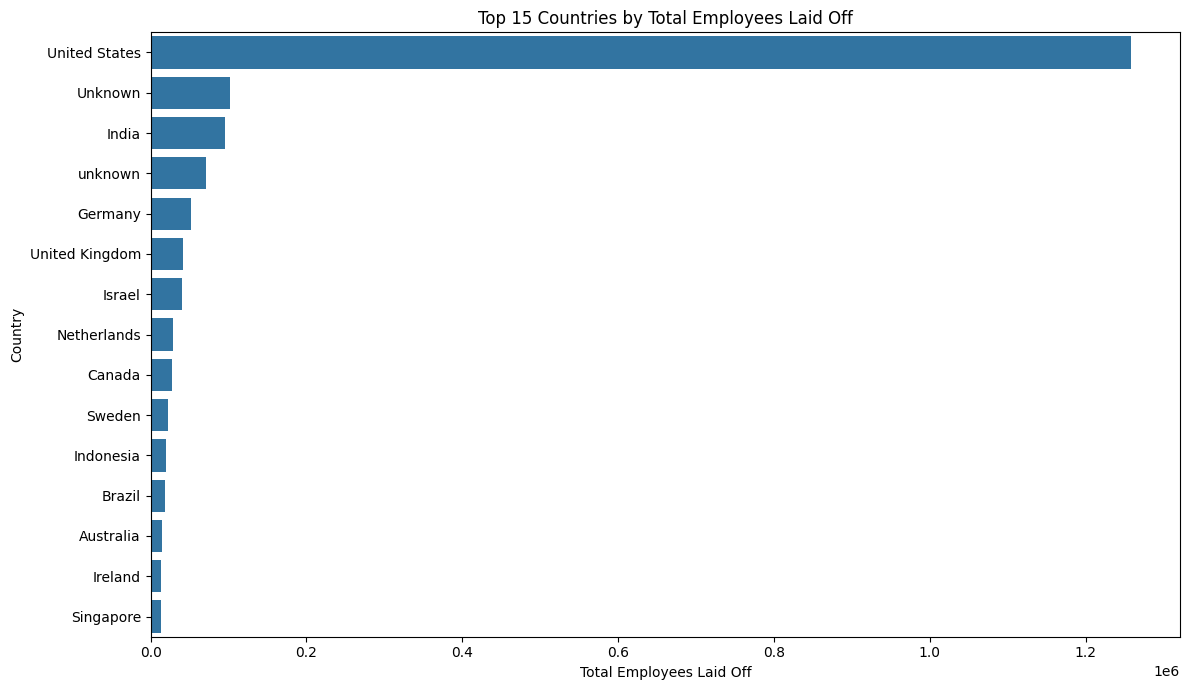

In [20]:
country_layoffs = (
    df.groupby("country")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
)

display(
    country_layoffs.head(15).to_frame(
        "Total Employees Laid Off"
    )
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=country_layoffs.head(15).values,
    y=country_layoffs.head(15).index
)

plt.title("Top 15 Countries by Total Employees Laid Off")
plt.xlabel("Total Employees Laid Off")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [21]:
layoff_counts = df["total_laid_off"].dropna()

mean_layoffs = layoff_counts.mean()
variance_layoffs = layoff_counts.var()

print("Mean of Total Laid Off     :", mean_layoffs)
print("Variance of Total Laid Off :", variance_layoffs)

print(
    "\nVariance / Mean ratio:",
    variance_layoffs / mean_layoffs
)

if variance_layoffs > mean_layoffs * 2:
    print(
        "\nConclusion: The data is strongly overdispersed. "
        "A simple Poisson distribution is not appropriate."
    )
else:
    print(
        "\nConclusion: The variance is relatively close to "
        "the mean, so Poisson may be considered."
    )

Mean of Total Laid Off     : 333.3629316420014
Variance of Total Laid Off : 1470853.009755237

Variance / Mean ratio: 4412.167251201123

Conclusion: The data is strongly overdispersed. A simple Poisson distribution is not appropriate.


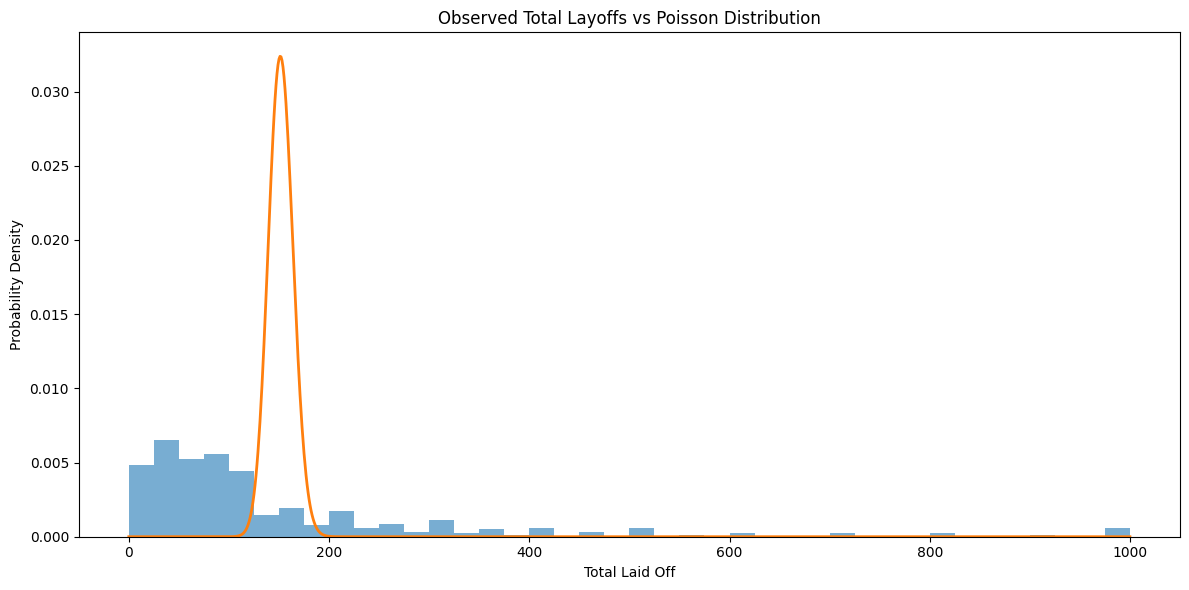

In [22]:
from scipy.stats import poisson

poisson_data = layoff_counts[
    layoff_counts <= 1000
]

lambda_value = poisson_data.mean()

x = np.arange(
    0,
    min(1000, int(poisson_data.max())) + 1
)

poisson_probabilities = poisson.pmf(
    x,
    lambda_value
)

plt.figure(figsize=(12, 6))

plt.hist(
    poisson_data,
    bins=40,
    density=True,
    alpha=0.6
)

plt.plot(
    x,
    poisson_probabilities,
    linewidth=2
)

plt.title(
    "Observed Total Layoffs vs Poisson Distribution"
)

plt.xlabel("Total Laid Off")
plt.ylabel("Probability Density")

plt.tight_layout()
plt.show()

In [23]:
us = df.loc[
    df["is_us"] == True,
    "total_laid_off"
].dropna()

non_us = df.loc[
    df["is_us"] == False,
    "total_laid_off"
].dropna()

print("US observations     :", len(us))
print("Non-US observations :", len(non_us))

print("\nUS mean     :", us.mean())
print("Non-US mean :", non_us.mean())

t_stat_final, p_ttest = stats.ttest_ind(
    us,
    non_us,
    equal_var=False
)

print("\nT-statistic:", t_stat_final)
print("P-value:", p_ttest)

alpha = 0.05

if p_ttest < alpha:
    print("\nDecision: Reject H0")
    print(
        "Conclusion: There is a statistically significant "
        "difference between the mean layoffs of US and non-US records."
    )
else:
    print("\nDecision: Fail to Reject H0")
    print(
        "Conclusion: There is insufficient evidence of a "
        "difference between the two means."
    )

US observations     : 3521
Non-US observations : 2155

US mean     : 357.39278614030104
Non-US mean : 294.10116009280745

T-statistic: 2.045133314897366
P-value: 0.04088953694433973

Decision: Reject H0
Conclusion: There is a statistically significant difference between the mean layoffs of US and non-US records.


In [24]:
bins = [-0.01, 10, 25, 50, 100]
labels = ["Low", "Moderate", "High", "Severe"]

df["layoff_severity"] = pd.cut(
    df["percentage_laid_off"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("Layoff Severity Distribution:")
display(
    df["layoff_severity"]
    .value_counts()
    .sort_index()
    .to_frame("Number of Records")
)

contingency_table = pd.crosstab(
    df["is_us"],
    df["layoff_severity"]
)

print("\nContingency Table:")
display(contingency_table)

Layoff Severity Distribution:


,Number of Records
layoff_severity,
Low,1595
Moderate,2591
High,824
Severe,666



Contingency Table:


layoff_severity,Low,Moderate,High,Severe
is_us,,,,
False,549,978,338,290
True,1046,1613,486,376


In [25]:
chi2_final, p_chi, dof_final, expected_final = (
    stats.chi2_contingency(
        contingency_table
    )
)

print("Chi-square statistic:", chi2_final)
print("Degrees of freedom :", dof_final)
print("P-value            :", p_chi)

alpha = 0.05

if p_chi < alpha:
    print("\nDecision: Reject H0")
    print(
        "Conclusion: US/non-US status and layoff severity "
        "are statistically associated."
    )
else:
    print("\nDecision: Fail to Reject H0")
    print(
        "Conclusion: There is insufficient evidence of an "
        "association between US/non-US status and layoff severity."
    )

Chi-square statistic: 20.627254392007437
Degrees of freedom : 3
P-value            : 0.00012580865722178233

Decision: Reject H0
Conclusion: US/non-US status and layoff severity are statistically associated.


In [26]:
top_industries = (
    df["industry"]
    .value_counts()
    .head(5)
    .index
)

print("Industries selected for ANOVA:")
for industry in top_industries:
    print("-", industry)

Industries selected for ANOVA:
- Finance
- Healthcare
- Retail
- Consumer
- Other


In [27]:
industry_groups = {}

for industry in top_industries:

    values = df.loc[
        df["industry"] == industry,
        "percentage_laid_off"
    ].dropna()

    industry_groups[industry] = values

    print(
        f"{industry}: "
        f"n={len(values)}, "
        f"mean={values.mean():.2f}%"
    )

anova_groups = list(industry_groups.values())

f_stat_final, p_anova = stats.f_oneway(
    *anova_groups
)

print("\nF-statistic:", f_stat_final)
print("P-value:", p_anova)

alpha = 0.05

if p_anova < alpha:
    print("\nDecision: Reject H0")
    print(
        "Conclusion: At least one industry's mean percentage "
        "laid off is statistically different."
    )
else:
    print("\nDecision: Fail to Reject H0")
    print(
        "Conclusion: There is insufficient evidence of a "
        "difference among the industry means."
    )

Finance: n=529, mean=24.08%
Healthcare: n=321, mean=32.47%
Retail: n=320, mean=29.08%
Consumer: n=312, mean=27.68%
Other: n=281, mean=24.79%

F-statistic: 5.6851961807731595
P-value: 0.00015164312631784822

Decision: Reject H0
Conclusion: At least one industry's mean percentage laid off is statistically different.


,Mean Percentage Laid Off
industry,
Healthcare,32.47
Retail,29.08
Consumer,27.68
Other,24.79
Finance,24.08


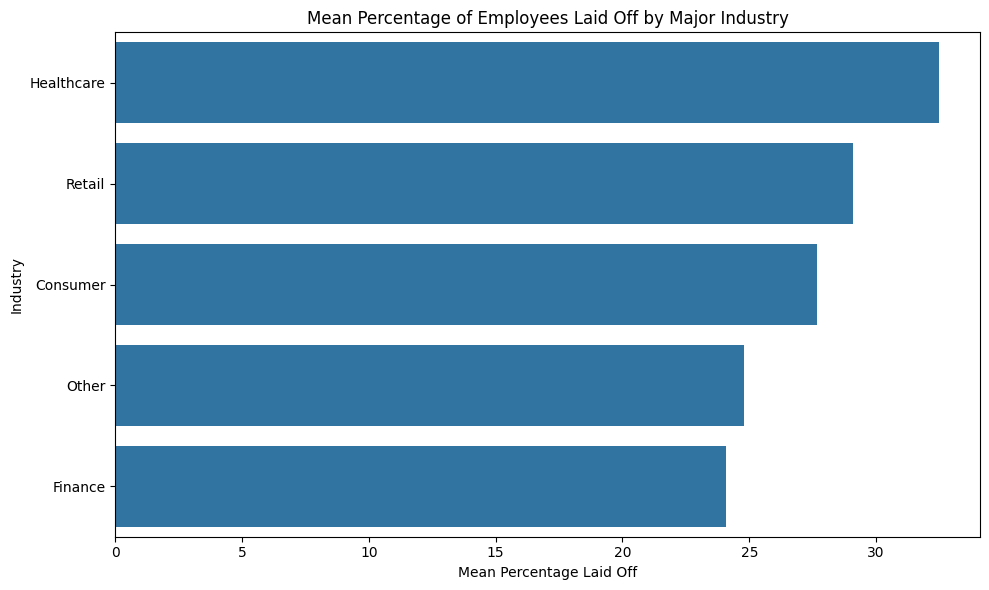

In [28]:
industry_mean_percentage = (
    df[df["industry"].isin(top_industries)]
    .groupby("industry")["percentage_laid_off"]
    .mean()
    .sort_values(ascending=False)
)

display(
    industry_mean_percentage.to_frame(
        "Mean Percentage Laid Off"
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=industry_mean_percentage.values,
    y=industry_mean_percentage.index
)

plt.title(
    "Mean Percentage of Employees Laid Off by Major Industry"
)

plt.xlabel("Mean Percentage Laid Off")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

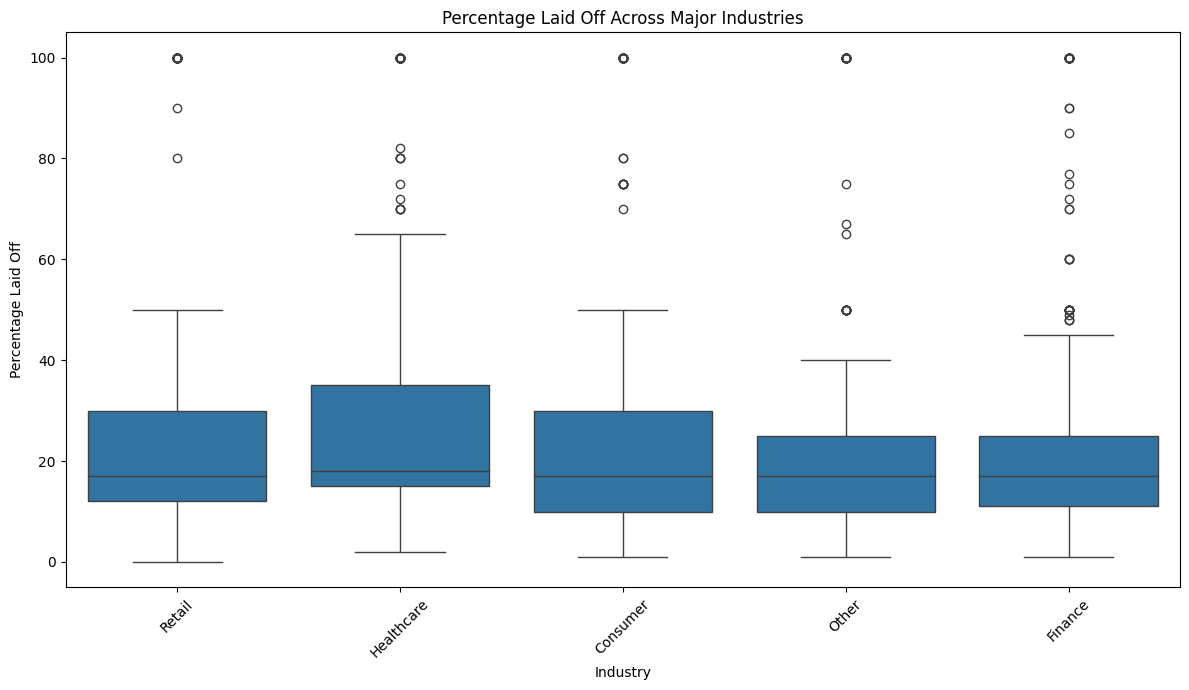

In [29]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df[
        df["industry"].isin(top_industries)
    ],
    x="industry",
    y="percentage_laid_off"
)

plt.title(
    "Percentage Laid Off Across Major Industries"
)

plt.xlabel("Industry")
plt.ylabel("Percentage Laid Off")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

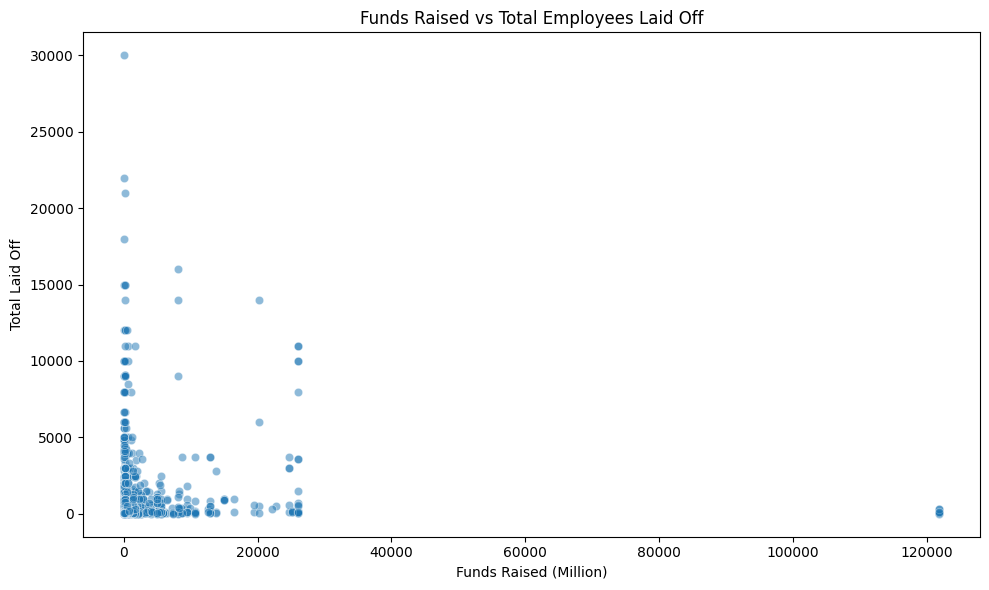

Pearson correlation: 0.06749942648947316
P-value: 3.579869472239739e-07


In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="funds_raised_mil",
    y="total_laid_off",
    alpha=0.5
)

plt.title(
    "Funds Raised vs Total Employees Laid Off"
)

plt.xlabel("Funds Raised (Million)")
plt.ylabel("Total Laid Off")

plt.tight_layout()
plt.show()

funding_subset = df[
    ["funds_raised_mil", "total_laid_off"]
].dropna()

funding_corr, funding_p = stats.pearsonr(
    funding_subset["funds_raised_mil"],
    funding_subset["total_laid_off"]
)

print("Pearson correlation:", funding_corr)
print("P-value:", funding_p)

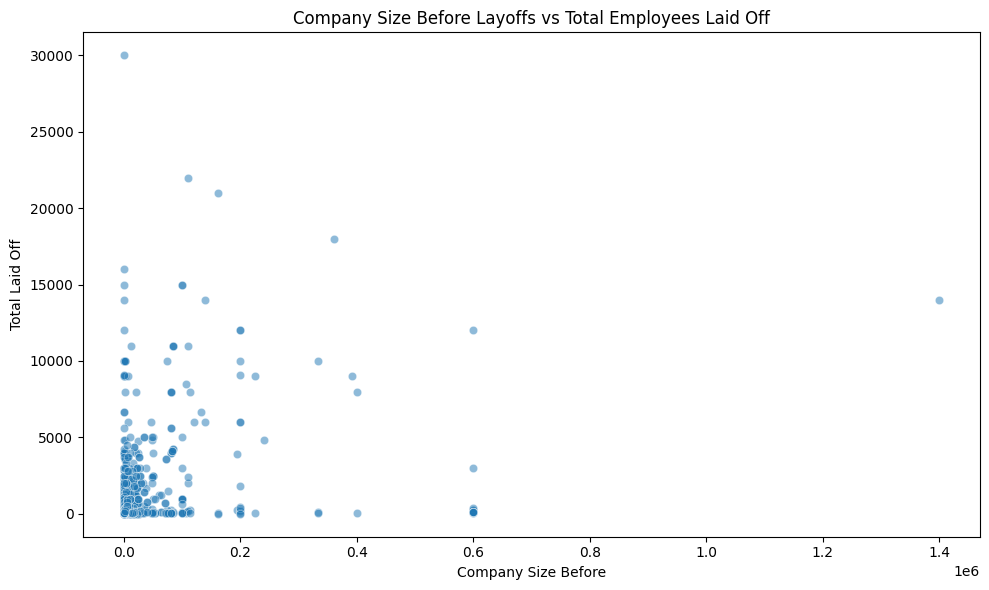

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="company_size_before",
    y="total_laid_off",
    alpha=0.5
)

plt.title(
    "Company Size Before Layoffs vs Total Employees Laid Off"
)

plt.xlabel("Company Size Before")
plt.ylabel("Total Laid Off")

plt.tight_layout()
plt.show()

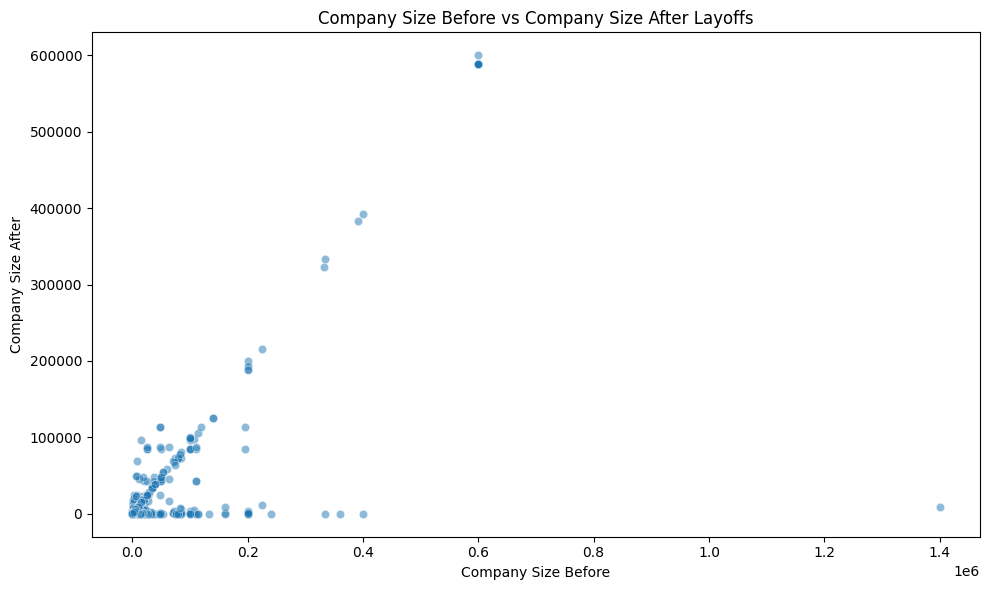

In [32]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="company_size_before",
    y="company_size_after",
    alpha=0.5
)

plt.title(
    "Company Size Before vs Company Size After Layoffs"
)

plt.xlabel("Company Size Before")
plt.ylabel("Company Size After")

plt.tight_layout()
plt.show()

In [33]:
results = pd.DataFrame({
    "Test": [
        "Welch Independent T-Test",
        "Chi-Square Test",
        "One-Way ANOVA"
    ],

    "Test Statistic": [
        t_stat_final,
        chi2_final,
        f_stat_final
    ],

    "P-Value": [
        p_ttest,
        p_chi,
        p_anova
    ],

    "Alpha": [
        alpha,
        alpha,
        alpha
    ],

    "Decision": [
        "Reject H0" if p_ttest < alpha
        else "Fail to Reject H0",

        "Reject H0" if p_chi < alpha
        else "Fail to Reject H0",

        "Reject H0" if p_anova < alpha
        else "Fail to Reject H0"
    ]
})

display(results)

,Test,Test Statistic,P-Value,Alpha,Decision
0,Welch Independent T-Test,2.05,0.04,0.05,Reject H0
1,Chi-Square Test,20.63,0.00,0.05,Reject H0
2,One-Way ANOVA,5.69,0.00,0.05,Reject H0


In [34]:
print("=" * 70)
print("FINAL EDA SUMMARY")
print("=" * 70)

print("\nDataset:")
print("Records  :", len(df))
print("Features :", len(df.columns))

if "year" in df.columns:
    print("\nYear Range:")
    print(df["year"].min(), "to", df["year"].max())

print("\nTop Industry by Number of Records:")
print(industry_counts.index[0])
print("Records:", industry_counts.iloc[0])

highest_year = year_summary["Total_Laid_Off"].idxmax()

print("\nYear with Highest Total Layoffs:")
print(
    highest_year,
    "->",
    f"{year_summary.loc[highest_year, 'Total_Laid_Off']:,.0f}",
    "employees"
)

largest_industry = industry_layoffs.index[0]

print("\nIndustry with Highest Total Layoffs:")
print(
    largest_industry,
    "->",
    f"{industry_layoffs.iloc[0]:,.0f}",
    "employees"
)

print("\nTotal Laid Off:")
print("Mean   :", df["total_laid_off"].mean())
print("Median :", df["total_laid_off"].median())
print("Maximum:", df["total_laid_off"].max())

print("\nPercentage Laid Off:")
print("Mean   :", df["percentage_laid_off"].mean())
print("Median :", df["percentage_laid_off"].median())

if "is_weekend" in df.columns:
    weekend_records = df["is_weekend"].sum()
    print("\nWeekend Records:")
    print(weekend_records, "out of", len(df))
    print(
        "Percentage:",
        f"{weekend_records / len(df) * 100:.2f}%"
    )

FINAL EDA SUMMARY

Dataset:
Records  : 5676
Features : 22

Year Range:
2020 to 2026

Top Industry by Number of Records:
Finance
Records: 529

Year with Highest Total Layoffs:
2023 -> 547,432 employees

Industry with Highest Total Layoffs:
Consumer -> 180,321 employees

Total Laid Off:
Mean   : 333.3629316420014
Median : 95.0
Maximum: 30000.0

Percentage Laid Off:
Mean   : 26.1263830162086
Median : 17.0

Weekend Records:
247 out of 5676
Percentage: 4.35%


In [35]:
year_summary.to_csv(
    "year_wise_layoff_analysis.csv"
)

industry_layoffs.to_csv(
    "industry_wise_layoff_analysis.csv"
)

outlier_table.to_csv(
    "outlier_analysis.csv"
)

stats_table.to_csv(
    "descriptive_statistics.csv"
)

results.to_csv(
    "hypothesis_test_results.csv",
    index=False
)

correlation_matrix.to_csv(
    "correlation_matrix.csv"
)

print("All analysis tables have been saved successfully.")

All analysis tables have been saved successfully.


In [36]:
try:
    from google.colab import files

    print("Downloading analysis result files...")

    for output_file in [
        "year_wise_layoff_analysis.csv",
        "industry_wise_layoff_analysis.csv",
        "outlier_analysis.csv",
        "descriptive_statistics.csv",
        "hypothesis_test_results.csv",
        "correlation_matrix.csv"
    ]:
        files.download(output_file)

except ImportError:
    print(
        "Google Colab download is not available. "
        "The files are saved in the current working directory."
    )

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>